In [1]:
# SIT215 Assignment 3
# Integrated Intelligent System Project
# Jin Kim - 223715707

import math
import random
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
# ---------------------------------------------------------
# 1. Melbourne CBD Graph Environment
# ---------------------------------------------------------
# This graph reuses the 20-node / 37-edge structure from Assignment 1.
# In Assignment 3, the same structure is extended with distance, bumpiness,
# fuzzy safe speed, and replanning logic.

nodes = {
    "N1": ("Flinders Street Station", -37.8183, 144.9671),
    "N2": ("Federation Square", -37.8179, 144.9691),
    "N3": ("St Paul's Cathedral", -37.8170, 144.9677),
    "N4": ("Degraves St Entrance", -37.8176, 144.9652),
    "N5": ("Collins & Swanston Jct", -37.8158, 144.9668),
    "N6": ("Bourke St Mall East", -37.8136, 144.9655),
    "N7": ("Victoria Market", -37.8067, 144.9567),
    "N8": ("Melbourne Central Station", -37.8101, 144.9628),
    "N9": ("State Library Victoria", -37.8099, 144.9653),
    "N10": ("QV Melbourne", -37.8107, 144.9650),
    "N11": ("Chinatown", -37.8119, 144.9680),
    "N12": ("Hardware Lane", -37.8153, 144.9605),
    "N13": ("Elizabeth & Lonsdale Jct", -37.8112, 144.9601),
    "N14": ("Flagstaff Gardens", -37.8102, 144.9547),
    "N15": ("RMIT Building 8", -37.8087, 144.9632),
    "N16": ("Emporium Melbourne", -37.8124, 144.9636),
    "N17": ("Southern Cross Station", -37.8183, 144.9525),
    "N18": ("Docklands Waterfront", -37.8152, 144.9442),
    "N19": ("Crown Melbourne", -37.8226, 144.9604),
    "N20": ("Parliament House", -37.8110, 144.9737),
}

# Edges from Assignment 1.
# The third value is the original abstract cost:
# 1 = smooth / standard road
# 2 = moderate / busy road
# 3 = rough / constrained laneway
edges = [
    ("N1", "N2", 2), ("N1", "N3", 1), ("N1", "N19", 1),

    ("N2", "N3", 2), ("N2", "N5", 2),

    ("N3", "N4", 3), ("N3", "N5", 1),

    ("N4", "N6", 3),

    ("N5", "N6", 2), ("N5", "N8", 1), ("N5", "N10", 1), ("N5", "N15", 1),

    ("N6", "N11", 2), ("N6", "N12", 3), ("N6", "N16", 2),

    ("N7", "N13", 1), ("N7", "N14", 1), ("N7", "N15", 1),

    ("N8", "N9", 1), ("N8", "N10", 2), ("N8", "N11", 2),
    ("N8", "N13", 1), ("N8", "N15", 1), ("N8", "N16", 1),

    ("N9", "N10", 2), ("N9", "N15", 1),

    ("N10", "N11", 2), ("N10", "N15", 1),

    ("N11", "N12", 3), ("N11", "N16", 2),

    ("N12", "N13", 3),

    ("N13", "N14", 1), ("N13", "N17", 1),

    ("N14", "N17", 1),

    ("N17", "N18", 1),

    ("N19", "N20", 1),

    ("N20", "N9", 1),
]

In [4]:
# ---------------------------------------------------------
# 2. Distance and Bumpiness Helpers
# ---------------------------------------------------------

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Calculates approximate real-world distance between two latitude/longitude points.
    The result is in kilometres.
    """
    radius = 6371  # Earth radius in km

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = (
        math.sin(delta_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return radius * c


def old_cost_to_bumpiness_value(old_cost):
    """
    Converts the original Assignment 1 cost into a fuzzy bumpiness value.
    This keeps the Assignment 1 graph connected to Assignment 3 fuzzy logic.
    """
    if old_cost == 1:
        return 2.0      # Smooth
    elif old_cost == 2:
        return 5.0      # Moderate
    elif old_cost == 3:
        return 8.0      # Rough
    else:
        raise ValueError("Old cost must be 1, 2, or 3.")


def old_cost_to_bumpiness_label(old_cost):
    if old_cost == 1:
        return "Smooth"
    elif old_cost == 2:
        return "Moderate"
    elif old_cost == 3:
        return "Rough"
    else:
        raise ValueError("Old cost must be 1, 2, or 3.")

In [5]:
# ---------------------------------------------------------
# 2. Distance and Bumpiness Helpers
# ---------------------------------------------------------

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Calculates approximate real-world distance between two latitude/longitude points.
    The result is in kilometres.
    """
    radius = 6371  # Earth radius in km

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = (
        math.sin(delta_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return radius * c


def old_cost_to_bumpiness_value(old_cost):
    """
    Converts the original Assignment 1 cost into a fuzzy bumpiness value.
    This keeps the Assignment 1 graph connected to Assignment 3 fuzzy logic.
    """
    if old_cost == 1:
        return 2.0      # Smooth
    elif old_cost == 2:
        return 5.0      # Moderate
    elif old_cost == 3:
        return 8.0      # Rough
    else:
        raise ValueError("Old cost must be 1, 2, or 3.")


def old_cost_to_bumpiness_label(old_cost):
    if old_cost == 1:
        return "Smooth"
    elif old_cost == 2:
        return "Moderate"
    elif old_cost == 3:
        return "Rough"
    else:
        raise ValueError("Old cost must be 1, 2, or 3.")

In [6]:
# ---------------------------------------------------------
# 3. Build NetworkX Graph
# ---------------------------------------------------------

G = nx.Graph()

for node_id, (name, lat, lon) in nodes.items():
    G.add_node(
        node_id,
        name=name,
        lat=lat,
        lon=lon
    )

for u, v, old_cost in edges:
    name_u, lat_u, lon_u = nodes[u]
    name_v, lat_v, lon_v = nodes[v]

    distance = haversine_km(lat_u, lon_u, lat_v, lon_v)

    G.add_edge(
        u,
        v,
        old_cost=old_cost,
        distance_km=distance,
        bumpiness_value=old_cost_to_bumpiness_value(old_cost),
        bumpiness_label=old_cost_to_bumpiness_label(old_cost)
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 20
Number of edges: 37


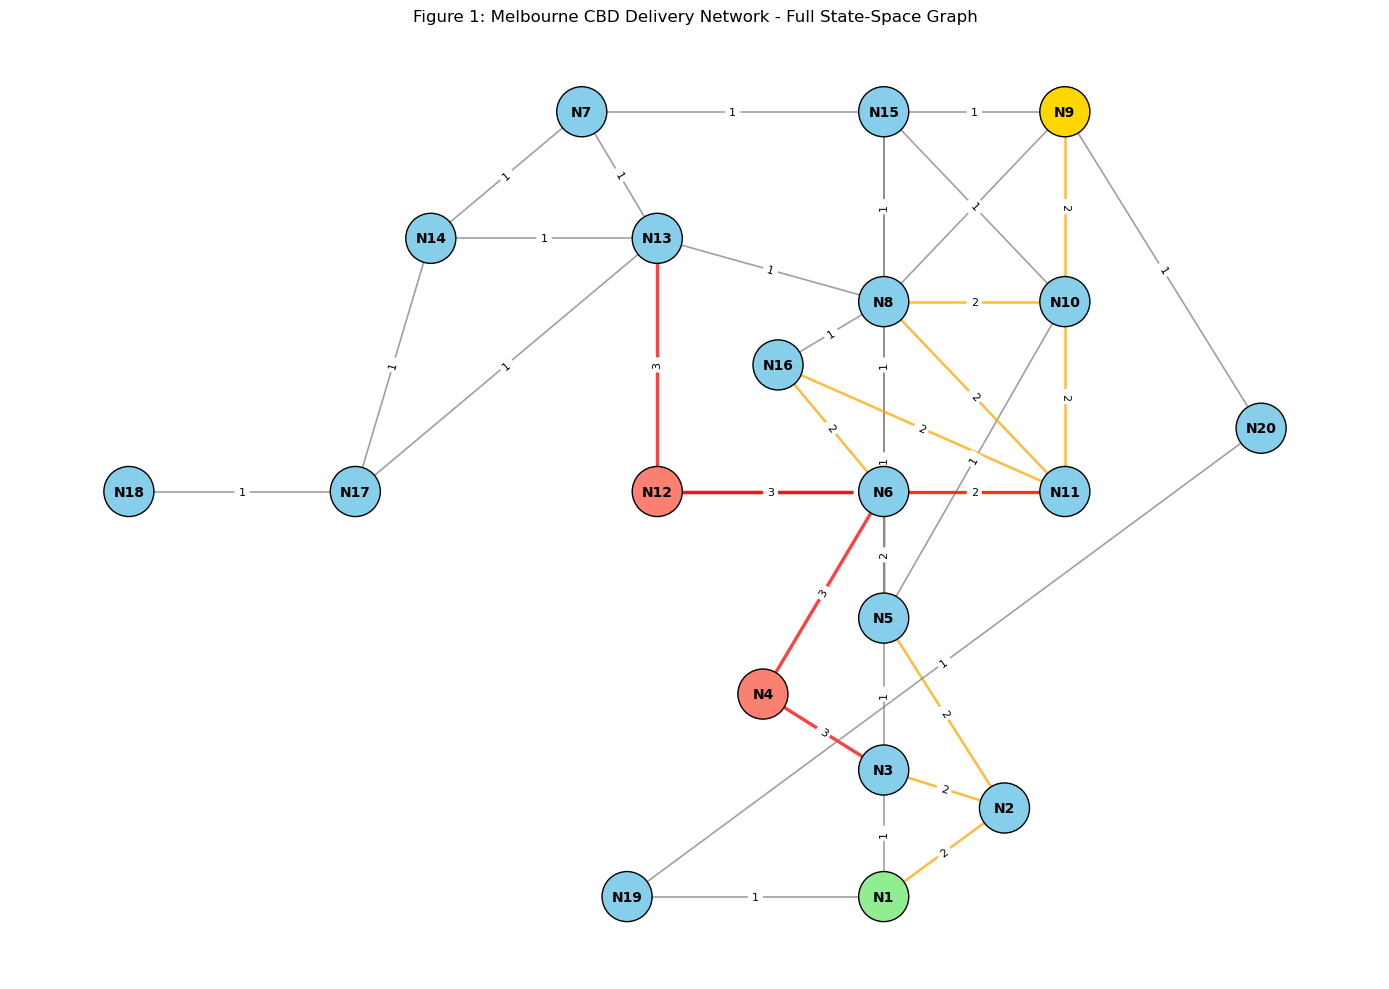

In [7]:
# ---------------------------------------------------------
# 4. Figure 1: Full State-Space Graph
# ---------------------------------------------------------

# Manual layout similar to Assignment 1 diagrams.
# This makes the graph easier to read than using raw GPS coordinates.
pos = {
    "N18": (-5, 0),
    "N17": (-3.5, 0),
    "N14": (-3, 2),
    "N7": (-2, 3),
    "N13": (-1.5, 2),
    "N12": (-1.5, 0),
    "N15": (0, 3),
    "N8": (0, 1.5),
    "N16": (-0.7, 1.0),
    "N6": (0, 0),
    "N5": (0, -1.0),
    "N4": (-0.8, -1.6),
    "N3": (0, -2.2),
    "N1": (0, -3.2),
    "N2": (0.8, -2.5),
    "N10": (1.2, 1.5),
    "N11": (1.2, 0),
    "N9": (1.2, 3),
    "N20": (2.5, 0.5),
    "N19": (-1.7, -3.2),
}

node_colours = []
for node in G.nodes():
    if node == "N1":
        node_colours.append("lightgreen")
    elif node == "N9":
        node_colours.append("gold")
    elif node in ["N4", "N12"]:
        node_colours.append("salmon")
    else:
        node_colours.append("skyblue")

edge_colours = []
edge_widths = []

for u, v, data in G.edges(data=True):
    if data["old_cost"] == 1:
        edge_colours.append("gray")
        edge_widths.append(1.2)
    elif data["old_cost"] == 2:
        edge_colours.append("orange")
        edge_widths.append(1.8)
    else:
        edge_colours.append("red")
        edge_widths.append(2.4)

plt.figure(figsize=(14, 10))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colours,
    node_size=1300,
    edgecolors="black"
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colours,
    width=edge_widths,
    alpha=0.75
)

nx.draw_networkx_labels(
    G,
    pos,
    labels={node: node for node in G.nodes()},
    font_size=10,
    font_weight="bold"
)

edge_labels = {
    (u, v): data["old_cost"]
    for u, v, data in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Figure 1: Melbourne CBD Delivery Network - Full State-Space Graph")
plt.axis("off")
plt.tight_layout()
plt.savefig("figure1_state_space_graph.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# ---------------------------------------------------------
# 5. Fuzzy Membership Functions
# ---------------------------------------------------------

def trapmf(x, abcd):
    a, b, c, d = abcd

    if x <= a:
        return 1.0 if a == b else 0.0
    elif a < x < b:
        return (x - a) / (b - a)
    elif b <= x <= c:
        return 1.0
    elif c < x < d:
        return (d - x) / (d - c)
    else:
        return 0.0


def trimf(x, abc):
    a, b, c = abc

    if x <= a or x >= c:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a)
    elif x == b:
        return 1.0
    elif b < x < c:
        return (c - x) / (c - b)
    else:
        return 0.0


def fragility_membership(x):
    return {
        "Low": trapmf(x, [0, 0, 2, 4]),
        "Medium": trimf(x, [3, 5, 7]),
        "High": trapmf(x, [6, 8, 10, 10])
    }


def bumpiness_membership(x):
    return {
        "Smooth": trapmf(x, [0, 0, 2, 4]),
        "Moderate": trimf(x, [3, 5, 7]),
        "Rough": trapmf(x, [6, 8, 10, 10])
    }


def speed_membership(label, x):
    if label == "Slow":
        return trapmf(x, [40, 40, 50, 65])
    elif label == "Medium":
        return trimf(x, [55, 70, 85])
    elif label == "Fast":
        return trapmf(x, [75, 90, 100, 100])
    else:
        raise ValueError("Speed label must be Slow, Medium, or Fast.")

In [9]:
# ---------------------------------------------------------
# 6. Fuzzy Rule Base and Inference
# ---------------------------------------------------------

rule_base = {
    ("Low", "Smooth"): "Fast",
    ("Low", "Moderate"): "Fast",
    ("Low", "Rough"): "Medium",

    ("Medium", "Smooth"): "Fast",
    ("Medium", "Moderate"): "Medium",
    ("Medium", "Rough"): "Slow",

    ("High", "Smooth"): "Medium",
    ("High", "Moderate"): "Slow",
    ("High", "Rough"): "Slow",
}


def fuzzy_safe_speed(fragility_value, bumpiness_value, show_details=False):
    """
    Mamdani fuzzy inference system.

    Inputs:
    - fragility_value: 0 to 10
    - bumpiness_value: 0 to 10

    Output:
    - crisp maximum safe speed between 40 and 100 km/h
    """
    frag_members = fragility_membership(fragility_value)
    bump_members = bumpiness_membership(bumpiness_value)

    x_speed = np.linspace(40, 100, 601)
    aggregated_output = np.zeros_like(x_speed)

    activated_rules = []

    for frag_label, frag_degree in frag_members.items():
        for bump_label, bump_degree in bump_members.items():
            rule_strength = min(frag_degree, bump_degree)

            if rule_strength > 0:
                output_label = rule_base[(frag_label, bump_label)]
                activated_rules.append(
                    (frag_label, bump_label, output_label, rule_strength)
                )

                clipped_output = np.array([
                    min(rule_strength, speed_membership(output_label, x))
                    for x in x_speed
                ])

                aggregated_output = np.maximum(aggregated_output, clipped_output)

    if aggregated_output.sum() == 0:
        crisp_speed = 70.0
    else:
        crisp_speed = np.sum(x_speed * aggregated_output) / np.sum(aggregated_output)

    if show_details:
        return crisp_speed, activated_rules, x_speed, aggregated_output

    return crisp_speed

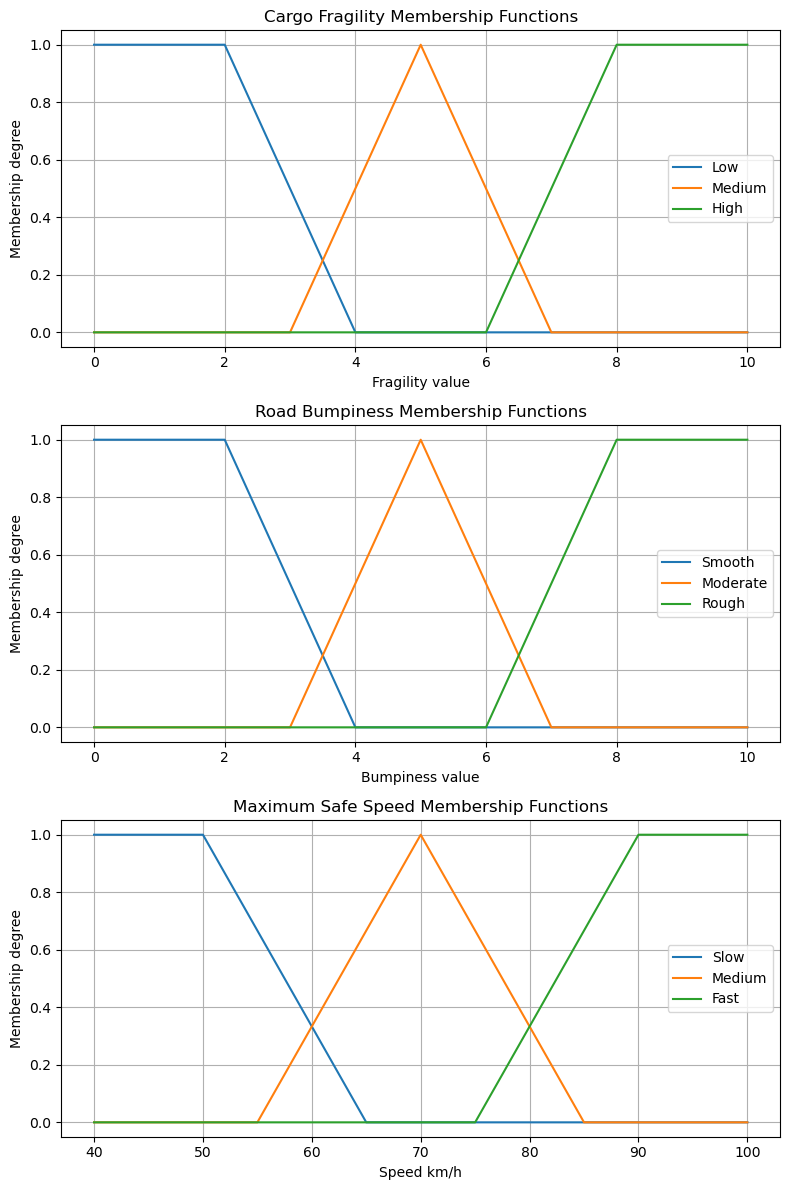

In [10]:
# ---------------------------------------------------------
# 7. Figure 2: Membership Function Plots
# ---------------------------------------------------------

x_input = np.linspace(0, 10, 201)
x_speed = np.linspace(40, 100, 601)

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# Cargo fragility
axes[0].plot(x_input, [fragility_membership(x)["Low"] for x in x_input], label="Low")
axes[0].plot(x_input, [fragility_membership(x)["Medium"] for x in x_input], label="Medium")
axes[0].plot(x_input, [fragility_membership(x)["High"] for x in x_input], label="High")
axes[0].set_title("Cargo Fragility Membership Functions")
axes[0].set_xlabel("Fragility value")
axes[0].set_ylabel("Membership degree")
axes[0].legend()
axes[0].grid(True)

# Road bumpiness
axes[1].plot(x_input, [bumpiness_membership(x)["Smooth"] for x in x_input], label="Smooth")
axes[1].plot(x_input, [bumpiness_membership(x)["Moderate"] for x in x_input], label="Moderate")
axes[1].plot(x_input, [bumpiness_membership(x)["Rough"] for x in x_input], label="Rough")
axes[1].set_title("Road Bumpiness Membership Functions")
axes[1].set_xlabel("Bumpiness value")
axes[1].set_ylabel("Membership degree")
axes[1].legend()
axes[1].grid(True)

# Safe speed
axes[2].plot(x_speed, [speed_membership("Slow", x) for x in x_speed], label="Slow")
axes[2].plot(x_speed, [speed_membership("Medium", x) for x in x_speed], label="Medium")
axes[2].plot(x_speed, [speed_membership("Fast", x) for x in x_speed], label="Fast")
axes[2].set_title("Maximum Safe Speed Membership Functions")
axes[2].set_xlabel("Speed km/h")
axes[2].set_ylabel("Membership degree")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig("figure2_membership_functions.png", dpi=300, bbox_inches="tight")
plt.show()

Representative fuzzy example
Cargo Fragility: 7
Road Bumpiness: 6
Maximum safe speed: 50.71 km/h

Activated rules:
('High', 'Moderate', 'Slow', 0.5)


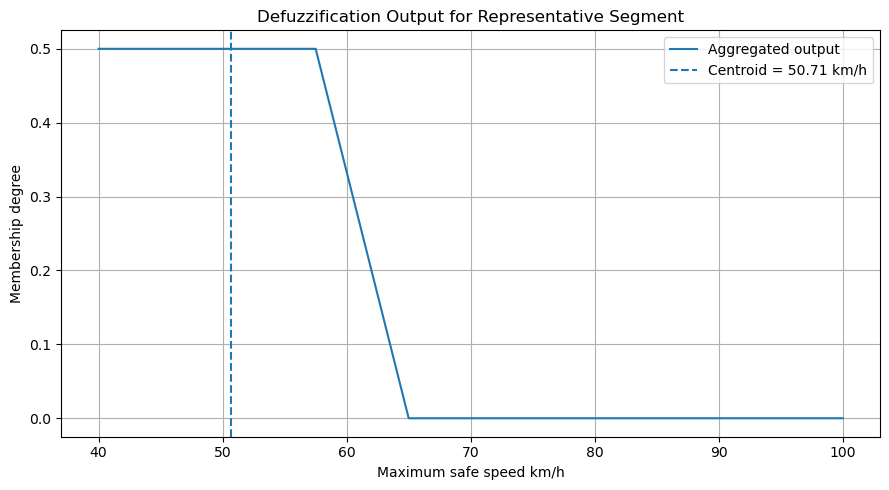

In [11]:
# ---------------------------------------------------------
# 8. Figure 3: Defuzzification Output Example
# ---------------------------------------------------------

example_fragility = 7
example_bumpiness = 6

example_speed, activated_rules, speed_domain, aggregated_output = fuzzy_safe_speed(
    example_fragility,
    example_bumpiness,
    show_details=True
)

print("Representative fuzzy example")
print("Cargo Fragility:", example_fragility)
print("Road Bumpiness:", example_bumpiness)
print("Maximum safe speed:", round(example_speed, 2), "km/h")
print("\nActivated rules:")
for rule in activated_rules:
    print(rule)

plt.figure(figsize=(9, 5))
plt.plot(speed_domain, aggregated_output, label="Aggregated output")
plt.axvline(
    example_speed,
    linestyle="--",
    label=f"Centroid = {example_speed:.2f} km/h"
)

plt.title("Defuzzification Output for Representative Segment")
plt.xlabel("Maximum safe speed km/h")
plt.ylabel("Membership degree")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figure3_defuzzification_output.png", dpi=300, bbox_inches="tight")
plt.show()

Representative fuzzy example
Cargo Fragility: 7
Road Bumpiness: 6
Maximum safe speed: 50.71 km/h

Activated rules:
('High', 'Moderate', 'Slow', 0.5)


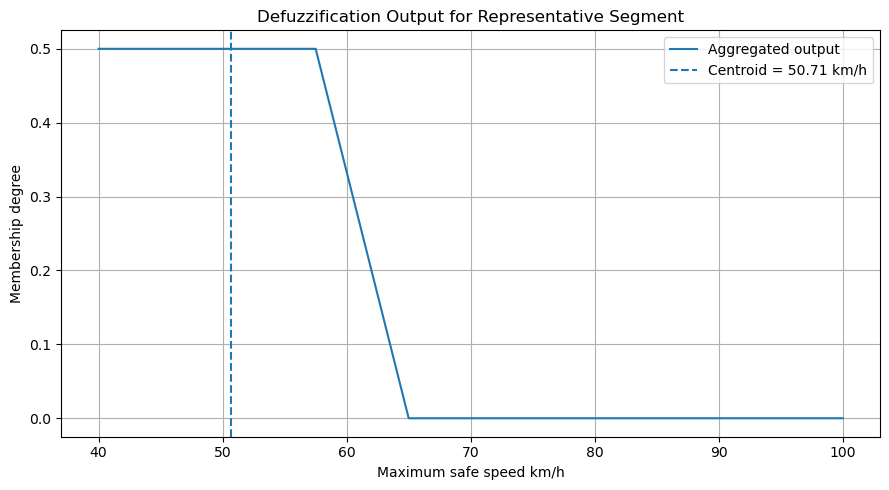

In [12]:
# ---------------------------------------------------------
# 8. Figure 3: Defuzzification Output Example
# ---------------------------------------------------------

example_fragility = 7
example_bumpiness = 6

example_speed, activated_rules, speed_domain, aggregated_output = fuzzy_safe_speed(
    example_fragility,
    example_bumpiness,
    show_details=True
)

print("Representative fuzzy example")
print("Cargo Fragility:", example_fragility)
print("Road Bumpiness:", example_bumpiness)
print("Maximum safe speed:", round(example_speed, 2), "km/h")
print("\nActivated rules:")
for rule in activated_rules:
    print(rule)

plt.figure(figsize=(9, 5))
plt.plot(speed_domain, aggregated_output, label="Aggregated output")
plt.axvline(
    example_speed,
    linestyle="--",
    label=f"Centroid = {example_speed:.2f} km/h"
)

plt.title("Defuzzification Output for Representative Segment")
plt.xlabel("Maximum safe speed km/h")
plt.ylabel("Membership degree")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figure3_defuzzification_output.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ---------------------------------------------------------
# 9. A* Search Implementation
# ---------------------------------------------------------

def straight_line_distance_km(node_a, node_b):
    """
    Straight-line distance between two nodes using their latitude and longitude.
    This is used for the admissible heuristic.
    """
    _, lat_a, lon_a = nodes[node_a]
    _, lat_b, lon_b = nodes[node_b]

    return haversine_km(lat_a, lon_a, lat_b, lon_b)


def heuristic_minutes(node, goal, max_speed=100):
    """
    Admissible heuristic:
    straight-line distance divided by the maximum possible speed.

    Since 100 km/h is the fastest possible speed in this system,
    this does not overestimate the true remaining travel time.
    """
    return (straight_line_distance_km(node, goal) / max_speed) * 60


def astar_search(graph, start, goal, edge_cost_function):
    """
    Custom A* implementation with a full search trace.

    edge_cost_function(u, v, data) returns edge cost in minutes.
    """
    open_heap = []
    heapq.heappush(open_heap, (0, start))

    came_from = {}

    g_score = {node: float("inf") for node in graph.nodes()}
    g_score[start] = 0

    visited = set()
    trace_rows = []

    while open_heap:
        current_f, current = heapq.heappop(open_heap)

        if current in visited:
            continue

        visited.add(current)

        h_value = heuristic_minutes(current, goal)
        f_value = g_score[current] + h_value

        trace_rows.append({
            "Expanded Node": current,
            "g(n) minutes": round(g_score[current], 4),
            "h(n) minutes": round(h_value, 4),
            "f(n) minutes": round(f_value, 4)
        })

        if current == goal:
            path = []
            temp = current

            while temp in came_from:
                path.append(temp)
                temp = came_from[temp]

            path.append(start)
            path.reverse()

            return path, g_score[current], pd.DataFrame(trace_rows)

        for neighbour in graph.neighbors(current):
            edge_data = graph[current][neighbour]
            edge_cost = edge_cost_function(current, neighbour, edge_data)
            tentative_g = g_score[current] + edge_cost

            if tentative_g < g_score[neighbour]:
                came_from[neighbour] = current
                g_score[neighbour] = tentative_g

                neighbour_h = heuristic_minutes(neighbour, goal)
                neighbour_f = tentative_g + neighbour_h

                heapq.heappush(open_heap, (neighbour_f, neighbour))

    return None, float("inf"), pd.DataFrame(trace_rows)


def route_distance_km(graph, path):
    total = 0

    for i in range(len(path) - 1):
        total += graph[path[i]][path[i + 1]]["distance_km"]

    return total


def route_time_minutes(graph, path, edge_cost_function):
    total = 0

    for i in range(len(path) - 1):
        u = path[i]
        v = path[i + 1]
        total += edge_cost_function(u, v, graph[u][v])

    return total

In [14]:
# ---------------------------------------------------------
# 10. Task 1: Baseline A* with Constant Speed
# ---------------------------------------------------------

start = "N1"
goal = "N9"

def baseline_edge_cost(u, v, data):
    """
    Baseline cost:
    all segments are travelled at constant speed 100 km/h.
    Cost is travel time in minutes.
    """
    constant_speed = 100
    return (data["distance_km"] / constant_speed) * 60


baseline_path, baseline_time, baseline_trace = astar_search(
    G,
    start,
    goal,
    baseline_edge_cost
)

baseline_distance = route_distance_km(G, baseline_path)

print("Baseline A* Path:")
print(" -> ".join(baseline_path))
print("Total distance:", round(baseline_distance, 3), "km")
print("Total time:", round(baseline_time, 3), "minutes")

baseline_trace

Baseline A* Path:
N1 -> N3 -> N5 -> N10 -> N9
Total distance: 0.99 km
Total time: 0.594 minutes


,Expanded Node,g(n) minutes,h(n) minutes,f(n) minutes
0,N1,0.0000,0.5684,0.5684
1,N3,0.0923,0.4903,0.5826
2,N5,0.1854,0.4015,0.5869
3,N10,0.5386,0.0557,0.5943
4,N9,0.5943,0.0000,0.5943


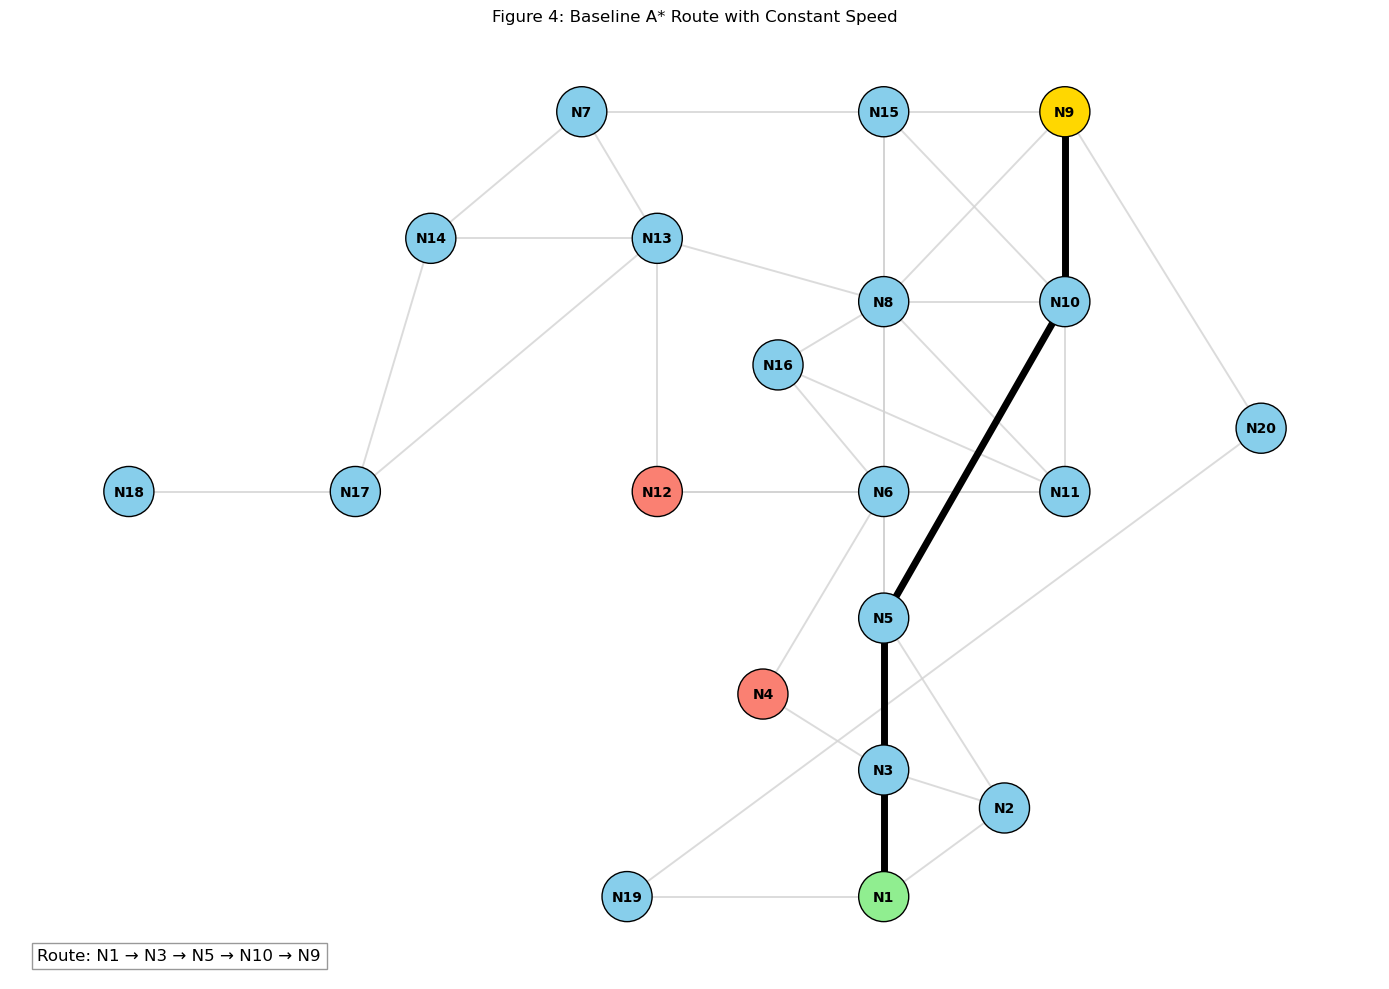

In [15]:
# ---------------------------------------------------------
# 11. Figure 4: Baseline A* Route
# ---------------------------------------------------------

def draw_route(graph, path, title, filename):
    plt.figure(figsize=(14, 10))

    # Draw all graph edges lightly
    nx.draw_networkx_edges(
        graph,
        pos,
        edge_color="lightgray",
        width=1.4,
        alpha=0.8
    )

    # Draw all nodes
    node_colours = []
    for node in graph.nodes():
        if node == start:
            node_colours.append("lightgreen")
        elif node == goal:
            node_colours.append("gold")
        elif node in ["N4", "N12"]:
            node_colours.append("salmon")
        else:
            node_colours.append("skyblue")

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=node_colours,
        node_size=1300,
        edgecolors="black"
    )

    nx.draw_networkx_labels(
        graph,
        pos,
        labels={node: node for node in graph.nodes()},
        font_size=10,
        font_weight="bold"
    )

    # Draw the route edges clearly
    route_edges = list(zip(path[:-1], path[1:]))

    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=route_edges,
        edge_color="black",
        width=5
    )

    # Add route text to avoid confusion
    route_text = "Route: " + " → ".join(path)
    plt.text(
        0.02,
        0.02,
        route_text,
        transform=plt.gca().transAxes,
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


draw_route(
    G,
    baseline_path,
    "Figure 4: Baseline A* Route with Constant Speed",
    "figure4_baseline_route.png"
)

In [16]:
# ---------------------------------------------------------
# 12. Task 3: Integrated A* with Fuzzy Safe Speed
# ---------------------------------------------------------

def fuzzy_edge_cost_factory(fragility_value):
    """
    Creates an edge cost function for a selected cargo fragility value.
    The edge cost is calculated using fuzzy safe speed.
    """
    def fuzzy_edge_cost(u, v, data):
        safe_speed = fuzzy_safe_speed(
            fragility_value,
            data["bumpiness_value"]
        )

        return (data["distance_km"] / safe_speed) * 60

    return fuzzy_edge_cost


fragility_cases = {
    "Low fragility": 2,
    "Medium fragility": 5,
    "High fragility": 8
}

integrated_results = []

for case_name, fragility_value in fragility_cases.items():
    cost_function = fuzzy_edge_cost_factory(fragility_value)

    path, total_time, trace = astar_search(
        G,
        start,
        goal,
        cost_function
    )

    total_distance = route_distance_km(G, path)

    integrated_results.append({
        "Case": case_name,
        "Fragility value": fragility_value,
        "Path": " -> ".join(path),
        "Total distance km": round(total_distance, 3),
        "Total time minutes": round(total_time, 3),
        "Baseline time minutes": round(baseline_time, 3),
        "Difference from baseline minutes": round(total_time - baseline_time, 3)
    })

integrated_df = pd.DataFrame(integrated_results)
integrated_df

,Case,Fragility value,Path,Total distance km,Total time minutes,Baseline time minutes,Difference from baseline minutes
0,Low fragility,2,N1 -> N3 -> N5 -> N10 -> N9,0.99,0.655,0.594,0.061
1,Medium fragility,5,N1 -> N3 -> N5 -> N10 -> N9,0.99,0.673,0.594,0.079
2,High fragility,8,N1 -> N3 -> N5 -> N10 -> N9,0.99,0.882,0.594,0.288


In [17]:
# ---------------------------------------------------------
# 13. Edge Safe Speed Examples for Report
# ---------------------------------------------------------

edge_speed_rows = []

for u, v, data in G.edges(data=True):
    row = {
        "Edge": f"{u}-{v}",
        "Distance km": round(data["distance_km"], 3),
        "Original Cost": data["old_cost"],
        "Bumpiness": data["bumpiness_label"],
        "Bumpiness value": data["bumpiness_value"]
    }

    for case_name, fragility_value in fragility_cases.items():
        row[f"Safe speed ({case_name})"] = round(
            fuzzy_safe_speed(fragility_value, data["bumpiness_value"]),
            2
        )

    edge_speed_rows.append(row)

edge_speed_df = pd.DataFrame(edge_speed_rows)

sample_edges = ["N1-N3", "N2-N5", "N3-N4", "N6-N12", "N8-N9"]

edge_speed_examples = edge_speed_df[
    edge_speed_df["Edge"].isin(sample_edges)
]

edge_speed_examples

,Edge,Distance km,Original Cost,Bumpiness,Bumpiness value,Safe speed (Low fragility),Safe speed (Medium fragility),Safe speed (High fragility)
1,N1-N3,0.154,1,Smooth,2.0,90.74,90.74,70.00
4,N2-N5,0.309,2,Moderate,5.0,90.74,70.00,49.26
5,N3-N4,0.230,3,Rough,8.0,70.00,49.26,49.26
13,N6-N12,0.478,3,Rough,8.0,70.00,49.26,49.26
18,N8-N9,0.221,1,Smooth,2.0,90.74,90.74,70.00


High fragility integrated route:
N1 -> N3 -> N5 -> N10 -> N9
Time: 0.882 minutes


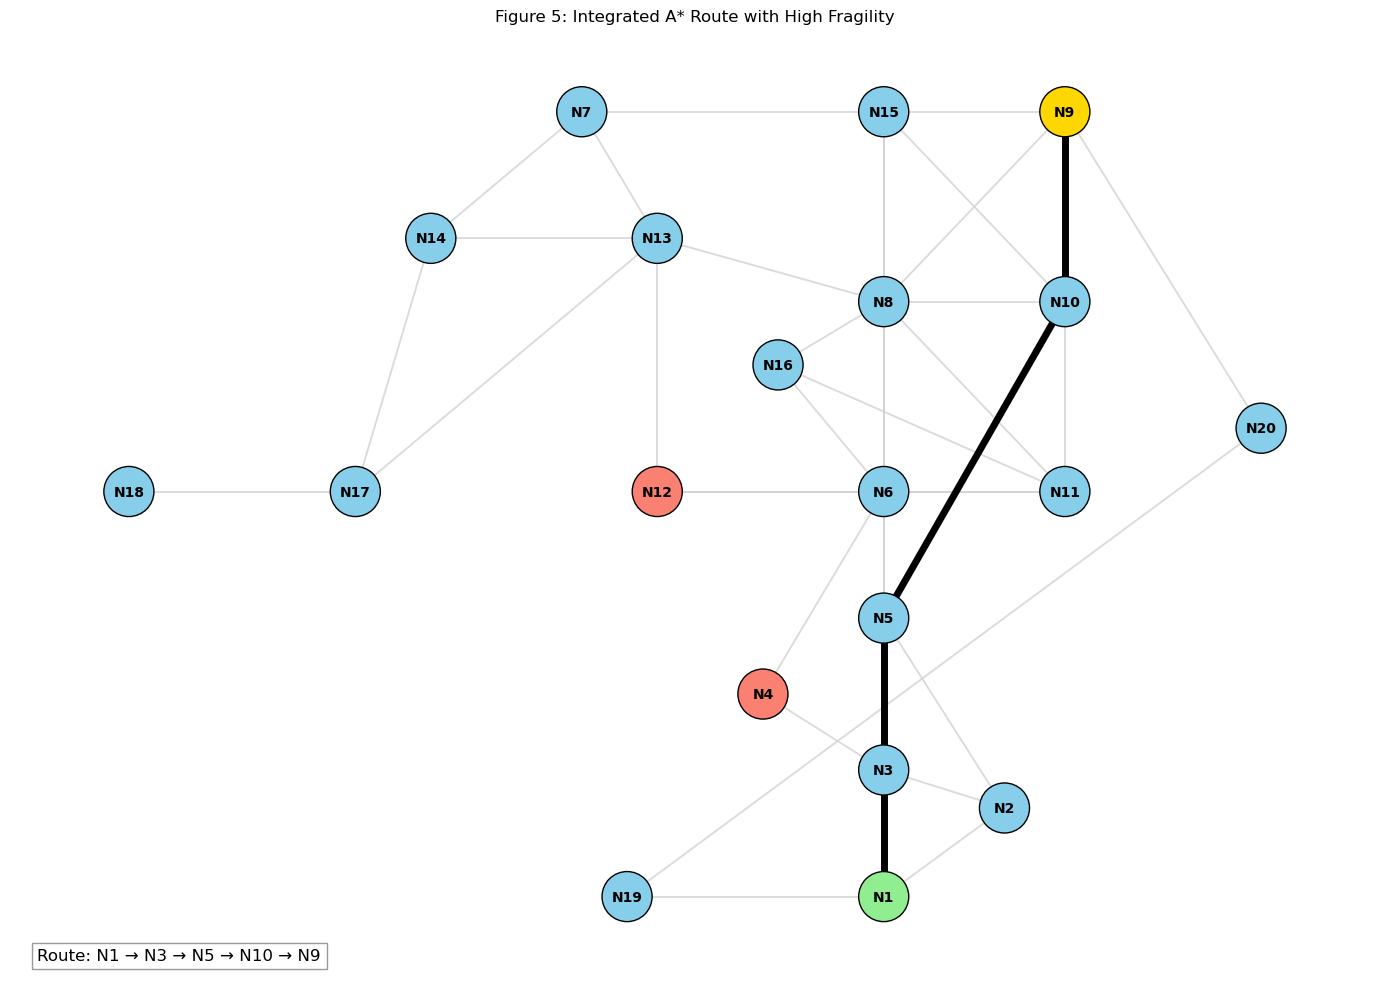

In [18]:
# ---------------------------------------------------------
# 14. Figure 5: Integrated A* Route with High Fragility
# ---------------------------------------------------------

high_fragility_cost = fuzzy_edge_cost_factory(8)

high_path, high_time, high_trace = astar_search(
    G,
    start,
    goal,
    high_fragility_cost
)

print("High fragility integrated route:")
print(" -> ".join(high_path))
print("Time:", round(high_time, 3), "minutes")

draw_route(
    G,
    high_path,
    "Figure 5: Integrated A* Route with High Fragility",
    "figure5_integrated_high_fragility_route.png"
)

In [19]:
# ---------------------------------------------------------
# 15. School-Zone Constraint Selection
# ---------------------------------------------------------

def select_school_zone_edges(graph, seed=215, proportion=0.60):
    """
    Selects 60% of graph edges using a fixed random seed.
    This makes the changed environment reproducible.
    """
    all_edges = sorted([
        tuple(sorted((u, v)))
        for u, v in graph.edges()
    ])

    random.seed(seed)

    selected_count = math.ceil(len(all_edges) * proportion)
    selected_edges = random.sample(all_edges, selected_count)

    return set(selected_edges)


school_zone_edges = select_school_zone_edges(
    G,
    seed=215,
    proportion=0.60
)

print("Total graph edges:", G.number_of_edges())
print("School-zone constrained edges:", len(school_zone_edges))
print("Constrained edges:")
for edge in sorted(school_zone_edges):
    print(edge)

Total graph edges: 37
School-zone constrained edges: 23
Constrained edges:
('N1', 'N19')
('N1', 'N2')
('N1', 'N3')
('N10', 'N11')
('N10', 'N15')
('N10', 'N5')
('N10', 'N8')
('N11', 'N12')
('N11', 'N16')
('N11', 'N6')
('N12', 'N13')
('N12', 'N6')
('N13', 'N14')
('N13', 'N17')
('N13', 'N7')
('N13', 'N8')
('N14', 'N17')
('N14', 'N7')
('N15', 'N7')
('N15', 'N9')
('N20', 'N9')
('N3', 'N4')
('N5', 'N8')


In [23]:
# ---------------------------------------------------------
# 16. Replanning Logic
# ---------------------------------------------------------

def get_current_node_after_20_percent(path):
    """
    Assignment requirement:
    after 20% of the originally planned route,
    measured by number of nodes visited and rounded up.

    Example:
    path has 5 nodes.
    ceil(20% of 5) = ceil(1) = 1 visited node.
    Therefore, current node is path[0] = N1.
    """
    visited_node_count = math.ceil(len(path) * 0.20)
    current_index = max(0, visited_node_count - 1)

    return path[current_index], current_index


def constrained_fuzzy_edge_cost_factory(fragility_value, constrained_edges):
    """
    If an edge is school-zone constrained, speed is capped at 40 km/h.
    Otherwise, the fuzzy safe speed is used.
    """
    def constrained_edge_cost(u, v, data):
        fuzzy_speed = fuzzy_safe_speed(
            fragility_value,
            data["bumpiness_value"]
        )

        edge_key = tuple(sorted((u, v)))

        if edge_key in constrained_edges:
            effective_speed = min(fuzzy_speed, 40)
        else:
            effective_speed = fuzzy_speed

        return (data["distance_km"] / effective_speed) * 60

    return constrained_edge_cost

In [21]:
# ---------------------------------------------------------
# 17. Task 3: Replanning Results
# ---------------------------------------------------------

replanning_results = []

for case_name, fragility_value in fragility_cases.items():
    # Original fuzzy-informed plan
    original_cost_function = fuzzy_edge_cost_factory(fragility_value)

    original_path, original_time, original_trace = astar_search(
        G,
        start,
        goal,
        original_cost_function
    )

    current_node, current_index = get_current_node_after_20_percent(original_path)

    travelled_path = original_path[:current_index + 1]

    # Updated environment after school-zone condition
    constrained_cost_function = constrained_fuzzy_edge_cost_factory(
        fragility_value,
        school_zone_edges
    )

    # Replan from current node, not from original start node
    remaining_path, remaining_time, replanning_trace = astar_search(
        G,
        current_node,
        goal,
        constrained_cost_function
    )

    # Actual travelled path:
    # travelled part + replanned remaining path
    actual_path = travelled_path[:-1] + remaining_path

    actual_time = route_time_minutes(
        G,
        actual_path,
        constrained_cost_function
    )

    actual_distance = route_distance_km(G, actual_path)
    original_distance = route_distance_km(G, original_path)

    replanning_results.append({
        "Case": case_name,
        "Original planned path": " -> ".join(original_path),
        "Current node after 20%": current_node,
        "Replanned remaining path": " -> ".join(remaining_path),
        "Actual travelled path": " -> ".join(actual_path),
        "Original distance km": round(original_distance, 3),
        "Actual distance km": round(actual_distance, 3),
        "Original fuzzy time minutes": round(original_time, 3),
        "Actual replanned time minutes": round(actual_time, 3),
        "Time change minutes": round(actual_time - original_time, 3)
    })

replanning_df = pd.DataFrame(replanning_results)
replanning_df

NameError: name 'get_current_node_after_20_percent' is not defined

In [22]:
# ---------------------------------------------------------
# 18. Optional Figure: Replanned Route for Low Fragility
# ---------------------------------------------------------

low_replanned_path_text = replanning_df.loc[
    replanning_df["Case"] == "Low fragility",
    "Actual travelled path"
].values[0]

low_replanned_path = low_replanned_path_text.split(" -> ")

draw_route(
    G,
    low_replanned_path,
    "Optional: Replanned Route under School-Zone Constraint",
    "optional_replanned_route_low_fragility.png"
)

NameError: name 'replanning_df' is not defined